In [1]:
!pip install kagglehub


In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "rajatkumar30/food-delivery-time"
)

print(path)

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|█████████████████████████████████████████| 978k/978k [00:01<00:00, 773kB/s]

Extracting files...
/Users/tridhajain/.cache/kagglehub/datasets/rajatkumar30/food-delivery-time/versions/1


In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "rajatkumar30/food-delivery-time"
)

print(path)

/Users/tridhajain/.cache/kagglehub/datasets/rajatkumar30/food-delivery-time/versions/1


In [4]:
import os

os.listdir(path)

['deliverytime.csv']

In [5]:
import pandas as pd

df = pd.read_csv(f"{path}/deliverytime.csv")

df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv(f"{path}/deliverytime.csv")

In [8]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [9]:
list(df.columns)

['ID',
 'Delivery_person_ID',
 'Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Type_of_order',
 'Type_of_vehicle',
 'Time_taken(min)']

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  object 
 9   Type_of_vehicle              45593 non-null  object 
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


In [11]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


In [12]:
df.describe(include='object')

,ID,Delivery_person_ID,Type_of_order,Type_of_vehicle
count,45593,45593,45593,45593
unique,45451,1320,4,4
top,7E+08,PUNERES01DEL01,Snack,motorcycle
freq,3,67,11533,26435


In [13]:
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Type_of_order                  0
Type_of_vehicle                0
Time_taken(min)                0
dtype: int64

In [14]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing.sort_values(
    by='Percentage',
    ascending=False
)

,Missing Values,Percentage
ID,0,0.0
Delivery_person_ID,0,0.0
Delivery_person_Age,0,0.0
Delivery_person_Ratings,0,0.0
Restaurant_latitude,0,0.0
Restaurant_longitude,0,0.0
Delivery_location_latitude,0,0.0
Delivery_location_longitude,0,0.0
Type_of_order,0,0.0
Type_of_vehicle,0,0.0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age              int64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Type_of_order                   object
Type_of_vehicle                 object
Time_taken(min)                  int64
dtype: object

In [17]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print()

ID
45451

Delivery_person_ID
1320

Delivery_person_Age
22

Delivery_person_Ratings
28

Restaurant_latitude
657

Restaurant_longitude
518

Delivery_location_latitude
4373

Delivery_location_longitude
4373

Type_of_order
4

Type_of_vehicle
4

Time_taken(min)
45



In [18]:
from math import radians, sin, cos, sqrt, atan2

In [20]:
# Function to calculate the geographical distance
# between restaurant and delivery location
# using the Haversine formula

def haversine(lat1, lon1, lat2, lon2):

    # Radius of Earth in kilometers
    R = 6371

    # Convert degrees to radians
    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    # Difference between coordinates
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = sin(dlat/2)**2 + \
        cos(lat1) * cos(lat2) * sin(dlon/2)**2

    c = 2 * atan2(
        sqrt(a),
        sqrt(1-a)
    )

    # Return distance in kilometers
    return R * c

In [21]:
# Create a new feature called Distance_km
# by calculating the distance for every order

df['Distance_km'] = df.apply(
    lambda x: haversine(
        x['Restaurant_latitude'],
        x['Restaurant_longitude'],
        x['Delivery_location_latitude'],
        x['Delivery_location_longitude']
    ),
    axis=1
)

In [22]:
# Display the newly created distance feature
# along with the target variable

df[['Distance_km', 'Time_taken(min)']].head()

,Distance_km,Time_taken(min)
0,3.025149,24
1,20.183530,33
2,1.552758,26
3,7.790401,21
4,6.210138,30


In [23]:
# Display statistical summary
# of delivery distances

df['Distance_km'].describe()

count    45593.000000
mean        99.303911
std       1099.731281
min          1.465067
25%          4.663493
50%          9.264281
75%         13.763977
max      19692.674606
Name: Distance_km, dtype: float64

In [24]:
# Check if any deliveries have
# zero distance between source and destination

df[df['Distance_km'] == 0]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min),Distance_km


In [25]:
# Display the top 10 largest delivery distances
# to identify potential outliers

df['Distance_km'].sort_values(
    ascending=False
).head(10)

33533    19692.674606
6788     19688.001288
2484     19683.687561
18826    19677.180552
9535     19070.408110
762      19070.337839
35535    19069.158946
22291    19068.246962
30633    19067.128547
43454    19066.150742
Name: Distance_km, dtype: float64

In [26]:
# Display statistical summary
# of delivery distance

df['Distance_km'].describe()

count    45593.000000
mean        99.303911
std       1099.731281
min          1.465067
25%          4.663493
50%          9.264281
75%         13.763977
max      19692.674606
Name: Distance_km, dtype: float64

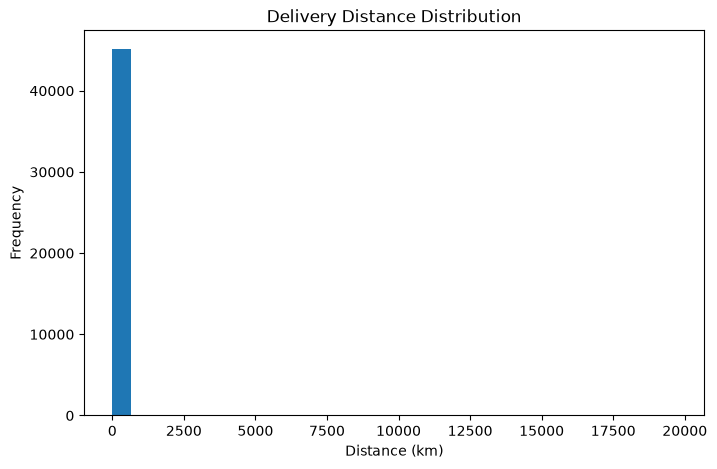

In [27]:
# Plot distribution of delivery distances

plt.figure(figsize=(8,5))

plt.hist(df['Distance_km'], bins=30)

plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.title('Delivery Distance Distribution')

plt.show()

In [28]:
# Find records with extremely large distances

df[df['Distance_km'] > 100][[
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude',
    'Distance_km'
]].head(20)

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Distance_km
92,-27.163303,78.057044,27.233303,78.127044,6048.631240
283,-27.165108,78.015053,27.225108,78.075053,6047.919478
289,-18.551440,-73.804855,18.611440,73.864855,16612.239055
425,-30.366322,-78.070453,30.496322,78.200453,17744.205087
534,-12.325461,-76.632278,12.385461,76.692278,17118.828366
583,-12.316967,76.603067,12.326967,76.613067,2740.280655
762,-23.359194,-85.325447,23.449194,85.415447,19070.337839
1059,-26.477750,-80.351569,26.487750,80.361569,18097.339322
1091,-15.546594,73.760431,15.606594,73.820431,3464.082720
1157,-12.337978,76.616792,12.387978,76.666792,2749.406397


In [29]:
# Count deliveries above 100 km

len(df[df['Distance_km'] > 100])

431

In [30]:
# Remove unrealistic deliveries

df = df[df['Distance_km'] <= 100]

In [31]:
df.shape

(45162, 12)

In [32]:
df['Distance_km'].describe()

count    45162.000000
mean         9.735396
std          5.608508
min          1.465067
25%          4.663412
50%          9.220209
75%         13.681490
max         20.969489
Name: Distance_km, dtype: float64

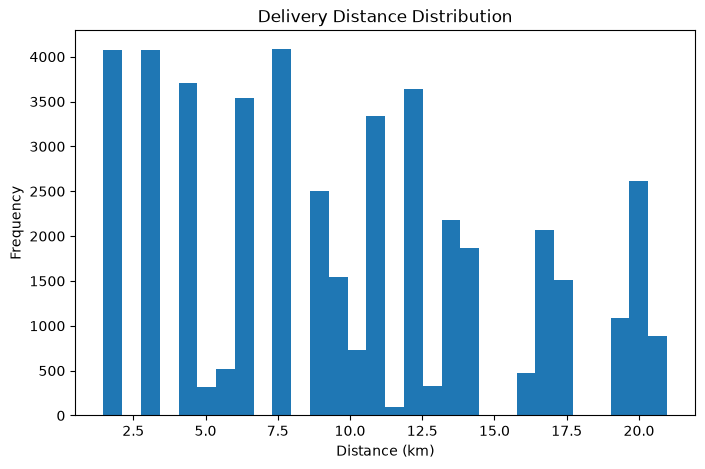

In [33]:
plt.figure(figsize=(8,5))

plt.hist(df['Distance_km'], bins=30)

plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.title('Delivery Distance Distribution')

plt.show()

In [34]:
len(df[df['Distance_km'] > 100])

0

In [35]:
df['Distance_km'].describe()

count    45162.000000
mean         9.735396
std          5.608508
min          1.465067
25%          4.663412
50%          9.220209
75%         13.681490
max         20.969489
Name: Distance_km, dtype: float64

In [36]:
# Create delivery experience groups

def experience_level(exp):

    if exp <= 25:
        return "Beginner"

    elif exp <= 35:
        return "Intermediate"

    else:
        return "Experienced"


df["Rider_Experience"] = df["Delivery_person_Age"].apply(
    experience_level
)

In [37]:
df["Rider_Experience"].value_counts()

Rider_Experience
Intermediate    23367
Beginner        12944
Experienced      8851
Name: count, dtype: int64

In [38]:
# Create rating groups

def rating_category(rating):

    if rating < 4:
        return "Low"

    elif rating < 4.7:
        return "Medium"

    else:
        return "High"


df["Rating_Category"] = (
    df["Delivery_person_Ratings"]
    .apply(rating_category)
)

In [39]:
df["Rating_Category"].value_counts()

Rating_Category
High      25271
Medium    18542
Low        1349
Name: count, dtype: int64

In [40]:
# Categorize delivery distances

def distance_category(distance):

    if distance <= 5:
        return "Short"

    elif distance <= 12:
        return "Medium"

    else:
        return "Long"


df["Distance_Category"] = (
    df["Distance_km"]
    .apply(distance_category)
)

In [41]:
df["Distance_Category"].value_counts()

Distance_Category
Medium    16788
Long      16210
Short     12164
Name: count, dtype: int64

In [42]:
# Average delivery time per vehicle

vehicle_analysis = (
    df.groupby("Type_of_vehicle")
      ["Time_taken(min)"]
      .mean()
      .sort_values()
)

print(vehicle_analysis)

Type_of_vehicle
electric_scooter     24.478400
scooter              24.478876
bicycle              26.039216
motorcycle           27.607372
Name: Time_taken(min), dtype: float64


In [43]:
# Average delivery time per order type

order_analysis = (
    df.groupby("Type_of_order")
      ["Time_taken(min)"]
      .mean()
      .sort_values()
)

print(order_analysis)

Type_of_order
Drinks     26.193408
Snack      26.276076
Buffet     26.292297
Meal       26.429492
Name: Time_taken(min), dtype: float64


In [44]:
# Select numerical columns

numeric_df = df.select_dtypes(
    include=["int64","float64"]
)

corr = numeric_df.corr()

corr

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min),Distance_km
Delivery_person_Age,1.000000,-0.082477,0.001784,-0.000956,0.001776,-0.000958,0.295763,-0.001728
Delivery_person_Ratings,-0.082477,1.000000,-0.010110,-0.013132,-0.010617,-0.013308,-0.337176,-0.101715
Restaurant_latitude,0.001784,-0.010110,1.000000,0.692187,0.999988,0.692240,0.013377,0.005963
Restaurant_longitude,-0.000956,-0.013132,0.692187,1.000000,0.692081,0.999999,0.007253,-0.009223
Delivery_location_latitude,0.001776,-0.010617,0.999988,0.692081,1.000000,0.692143,0.014983,0.010958
Delivery_location_longitude,-0.000958,-0.013308,0.692240,0.999999,0.692143,1.000000,0.007810,-0.007493
Time_taken(min),0.295763,-0.337176,0.013377,0.007253,0.014983,0.007810,1.000000,0.321703
Distance_km,-0.001728,-0.101715,0.005963,-0.009223,0.010958,-0.007493,0.321703,1.000000


In [45]:
# Save cleaned dataset for future modules

df.to_csv(
    "cleaned_data/food_delivery_cleaned.csv",
    index=False
)

print("Dataset saved successfully")

OSError: Cannot save file into a non-existent directory: 'cleaned_data'

In [46]:
import os

os.makedirs("cleaned_data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

In [47]:
df.to_csv(
    "cleaned_data/food_delivery_cleaned.csv",
    index=False
)

print("Dataset saved successfully")

Dataset saved successfully


In [48]:
# Import libraries
import networkx as nx

# Create graph
delivery_graph = nx.Graph()

In [49]:
# Add first 1000 deliveries as nodes

sample_df = df.head(1000)

for index, row in sample_df.iterrows():

    restaurant = (
        row['Restaurant_latitude'],
        row['Restaurant_longitude']
    )

    delivery = (
        row['Delivery_location_latitude'],
        row['Delivery_location_longitude']
    )

    delivery_graph.add_node(restaurant)
    delivery_graph.add_node(delivery)

In [50]:
for index, row in sample_df.iterrows():

    restaurant = (
        row['Restaurant_latitude'],
        row['Restaurant_longitude']
    )

    delivery = (
        row['Delivery_location_latitude'],
        row['Delivery_location_longitude']
    )

    delivery_graph.add_edge(
        restaurant,
        delivery,
        weight=row['Distance_km']
    )

In [51]:
print("Nodes:", delivery_graph.number_of_nodes())
print("Edges:", delivery_graph.number_of_edges())

Nodes: 1117
Edges: 813


ImportError: scipy._cyutility does not export expected C function slice_memviewslice

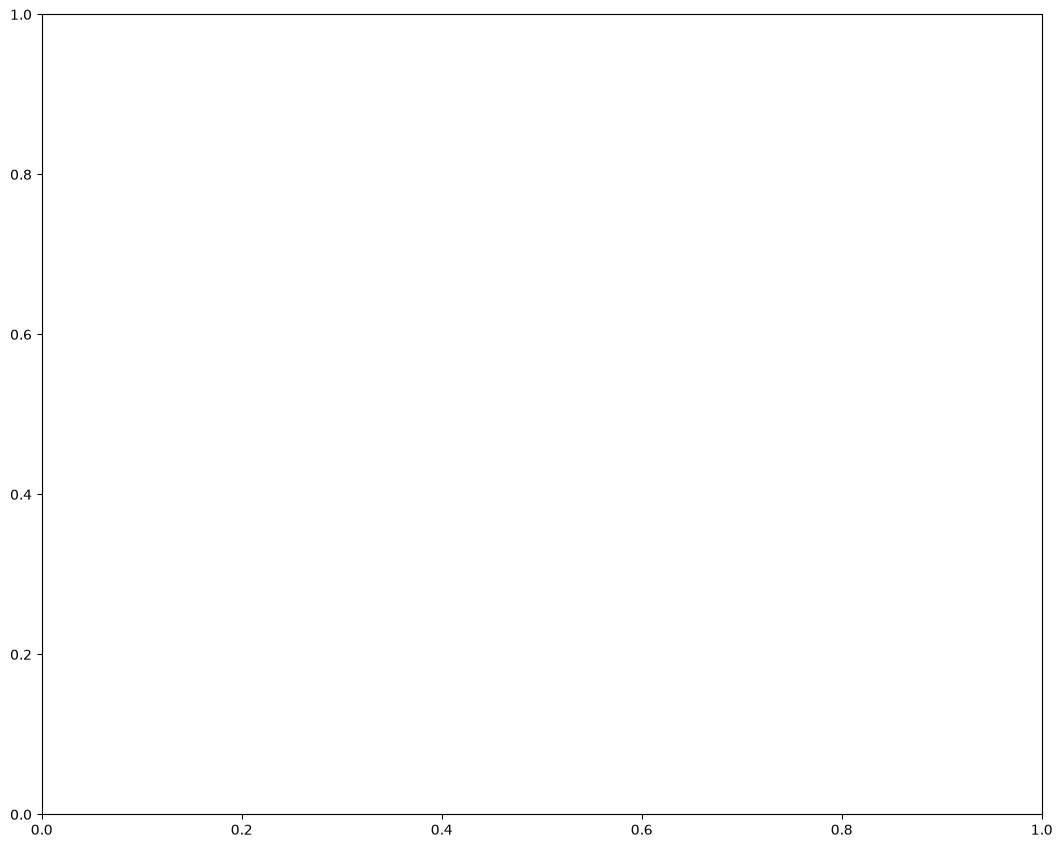

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

nx.draw(
    delivery_graph,
    node_size=10,
    with_labels=False
)

plt.show()

In [53]:
# Priority queue implementation

import heapq

In [54]:
# Create adjacency list

graph = {}

for u, v, data in delivery_graph.edges(data=True):

    if u not in graph:
        graph[u] = []

    if v not in graph:
        graph[v] = []

    graph[u].append((v, data['weight']))
    graph[v].append((u, data['weight']))

In [55]:
print(len(graph))

1117


In [56]:
def dijkstra(graph, start):

    # Initialize all distances
    distances = {
        node: float('inf')
        for node in graph
    }

    distances[start] = 0

    # Priority Queue
    pq = [(0, start)]

    while pq:

        current_distance, current_node = heapq.heappop(pq)

        if current_distance > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node]:

            distance = current_distance + weight

            if distance < distances[neighbor]:

                distances[neighbor] = distance

                heapq.heappush(
                    pq,
                    (distance, neighbor)
                )

    return distances

In [57]:
start_node = list(graph.keys())[0]

print(start_node)

(22.745049, 75.892471)


In [58]:
shortest_paths = dijkstra(
    graph,
    start_node
)

In [59]:
for node, distance in list(shortest_paths.items())[:10]:

    print(node, "->", distance)

(22.745049, 75.892471) -> 0
(22.765049, 75.912471) -> 3.0251492856775037
(22.835049, 75.982471) -> 13.611566722125085
(22.815049, 75.962471) -> 10.58713106938149
(12.913041, 77.683237) -> inf
(13.043041, 77.813237) -> inf
(13.003041, 77.773237) -> inf
(12.983041, 77.753237) -> inf
(12.914264, 77.6784) -> inf
(12.924264, 77.6884) -> inf


In [60]:
print(start_node)
print(list(shortest_paths.items())[:10])

(22.745049, 75.892471)
[((22.745049, 75.892471), 0), ((22.765049, 75.912471), 3.0251492856775037), ((22.835049, 75.982471), 13.611566722125085), ((22.815049, 75.962471), 10.58713106938149), ((12.913041, 77.683237), inf), ((13.043041, 77.813237), inf), ((13.003041, 77.773237), inf), ((12.983041, 77.753237), inf), ((12.914264, 77.6784), inf), ((12.924264, 77.6884), inf)]


In [61]:
# Select features

ml_df = df[[
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    'Distance_km',
    'Type_of_order',
    'Type_of_vehicle',
    'Time_taken(min)'
]]

ml_df.head()

,Delivery_person_Age,Delivery_person_Ratings,Distance_km,Type_of_order,Type_of_vehicle,Time_taken(min)
0,37,4.9,3.025149,Snack,motorcycle,24
1,34,4.5,20.183530,Snack,scooter,33
2,23,4.4,1.552758,Drinks,motorcycle,26
3,38,4.7,7.790401,Buffet,motorcycle,21
4,32,4.6,6.210138,Snack,scooter,30


In [62]:
ml_df.shape

(45162, 6)

In [1]:
from sklearn.preprocessing import LabelEncoder

le_order = LabelEncoder()
le_vehicle = LabelEncoder()

ml_df['Type_of_order'] = (
    le_order.fit_transform(
        ml_df['Type_of_order']
    )
)

ml_df['Type_of_vehicle'] = (
    le_vehicle.fit_transform(
        ml_df['Type_of_vehicle']
    )
)

ImportError: scipy._cyutility does not export expected C function slice_memviewslice

In [2]:
import sys
!{sys.executable} -m pip uninstall scipy scikit-learn -y

Found existing installation: scipy 1.18.0
Uninstalling scipy-1.18.0:
  Successfully uninstalled scipy-1.18.0
Found existing installation: scikit-learn 1.7.2
Uninstalling scikit-learn-1.7.2:
  Successfully uninstalled scikit-learn-1.7.2


In [3]:
import sys
!{sys.executable} -m pip install --upgrade scipy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 10.5 MB/s eta 0:00:00m eta 0:00:01:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 12.2 MB/s eta 0:00:0031m12.4 MB/s eta 0:00:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn]0m 1/2 [scikit-learn]


In [1]:
from sklearn.preprocessing import LabelEncoder


Scikit-learn working!


In [2]:
from sklearn.preprocessing import LabelEncoder
import sklearn
import scipy

print("Scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)
print("Everything is working!")

Scikit-learn: 1.9.0
SciPy: 1.18.0
Everything is working!


In [5]:
import pandas as pd

df = pd.read_csv("cleaned_data/food_delivery_cleaned.csv")

print(df.shape)
df.head()

(45162, 15)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min),Distance_km,Rider_Experience,Rating_Category,Distance_Category
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24,3.025149,Experienced,High,Short
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33,20.183530,Intermediate,Medium,Long
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26,1.552758,Beginner,Medium,Short
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21,7.790401,Experienced,High,Medium
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30,6.210138,Intermediate,Medium,Medium


In [6]:
print(df.columns)

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)', 'Distance_km', 'Rider_Experience', 'Rating_Category',
       'Distance_Category'],
      dtype='object')


In [7]:
from sklearn.preprocessing import LabelEncoder

le_order = LabelEncoder()
le_vehicle = LabelEncoder()

df['Type_of_order_encoded'] = le_order.fit_transform(df['Type_of_order'])
df['Type_of_vehicle_encoded'] = le_vehicle.fit_transform(df['Type_of_vehicle'])

df[['Type_of_order',
    'Type_of_order_encoded',
    'Type_of_vehicle',
    'Type_of_vehicle_encoded']].head()

,Type_of_order,Type_of_order_encoded,Type_of_vehicle,Type_of_vehicle_encoded
0,Snack,3,motorcycle,2
1,Snack,3,scooter,3
2,Drinks,1,motorcycle,2
3,Buffet,0,motorcycle,2
4,Snack,3,scooter,3


In [8]:
# Features (inputs)
X = df[
    [
        'Delivery_person_Age',
        'Delivery_person_Ratings',
        'Distance_km',
        'Type_of_order_encoded',
        'Type_of_vehicle_encoded'
    ]
]

# Target (output)
y = df['Time_taken(min)']

# Check shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Display first few rows
X.head()

Features shape: (45162, 5)
Target shape: (45162,)


,Delivery_person_Age,Delivery_person_Ratings,Distance_km,Type_of_order_encoded,Type_of_vehicle_encoded
0,37,4.9,3.025149,3,2
1,34,4.5,20.183530,3,3
2,23,4.4,1.552758,1,2
3,38,4.7,7.790401,0,2
4,32,4.6,6.210138,3,3


In [10]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display shapes
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (36129, 5)
Testing Features: (9033, 5)
Training Target: (36129,)
Testing Target: (9033,)


In [11]:
from sklearn.preprocessing import StandardScaler #normalize numerical output

# Create scaler object
scaler = StandardScaler()

# Columns to normalize
numeric_cols = [
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    'Distance_km'
]

# Fit scaler on training data
X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

# Apply same transformation on testing data
X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

# Display first rows
X_train.head()

,Delivery_person_Age,Delivery_person_Ratings,Distance_km,Type_of_order_encoded,Type_of_vehicle_encoded
24844,-1.328710,0.517891,-0.351713,0,1
33010,1.132542,0.206893,1.346836,1,3
16599,-0.801299,-0.415103,1.307141,0,2
35248,1.484149,0.517891,-1.192912,2,3
14293,-0.625495,1.139886,-1.174340,0,2


In [12]:
import os

# Create folder if not present
os.makedirs("../models", exist_ok=True)

# Save processed training and testing datasets
X_train.to_csv("../models/X_train.csv", index=False)
X_test.to_csv("../models/X_test.csv", index=False)

print("Processed data saved successfully.")

Processed data saved successfully.


In [13]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Numerical columns to scale
numerical_features = [
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    'Distance_km'
]

# Fit scaler on training data and transform
X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

# Transform test data using same scaler
X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

# Display first 5 rows
X_train.head()

,Delivery_person_Age,Delivery_person_Ratings,Distance_km,Type_of_order_encoded,Type_of_vehicle_encoded
24844,-1.328710,0.517891,-0.351713,0,1
33010,1.132542,0.206893,1.346836,1,3
16599,-0.801299,-0.415103,1.307141,0,2
35248,1.484149,0.517891,-1.192912,2,3
14293,-0.625495,1.139886,-1.174340,0,2


In [14]:
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save processed datasets
X_train.to_csv("../models/X_train.csv", index=False)
X_test.to_csv("../models/X_test.csv", index=False)

print("Datasets saved successfully!")

Datasets saved successfully!


In [15]:
from sklearn.linear_model import LinearRegression

# Create model
lr = LinearRegression()

# Train model
lr.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [16]:
# Predict delivery times
y_pred = lr.predict(X_test)

# Display first 10 predictions
print("Predictions:")
print(y_pred[:10])

Predictions:
[31.70392855 22.97333336 28.21416671 23.33058716 26.69373997 38.86352815
 28.38693428 21.10962629 38.52948208 25.01641229]


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 3))

MAE: 6.37
RMSE: 8.06
R² Score: 0.276


In [18]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²:", round(r2,3))

NameError: name 'rf_pred' is not defined

In [20]:
rf

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [21]:
rf_pred = rf.predict(X_test)

print(rf_pred[:10])

[28.37 24.08 36.87 28.69 41.45 44.07 31.33 27.02 37.72 31.58]


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 3))

MAE: 6.1
RMSE: 7.82
R²: 0.318


In [23]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                   Feature  Importance
2              Distance_km    0.454026
1  Delivery_person_Ratings    0.266503
0      Delivery_person_Age    0.180669
3    Type_of_order_encoded    0.066566
4  Type_of_vehicle_encoded    0.032236


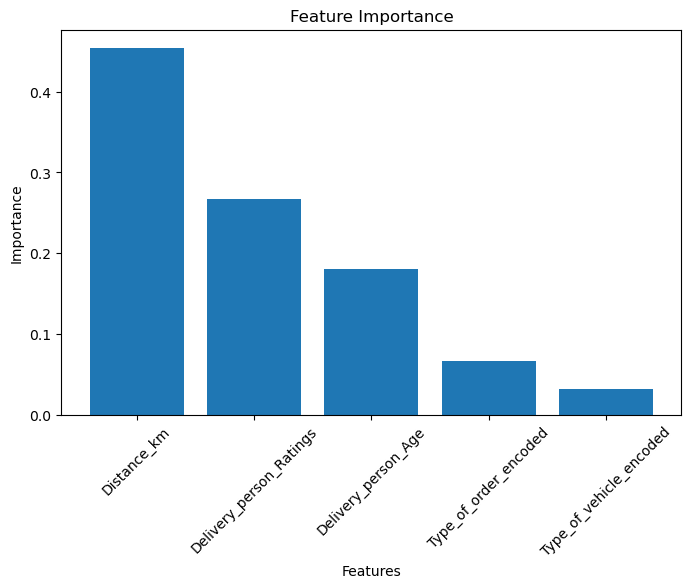

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=45)
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')

plt.show()

In [25]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [6.37, 6.10],
    'RMSE': [8.06, 7.82],
    'R2': [0.276, 0.318]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,6.37,8.06,0.276
1,Random Forest,6.10,7.82,0.318


In [26]:
import pickle

with open('../models/random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf, file)

print("Model saved successfully!")

Model saved successfully!


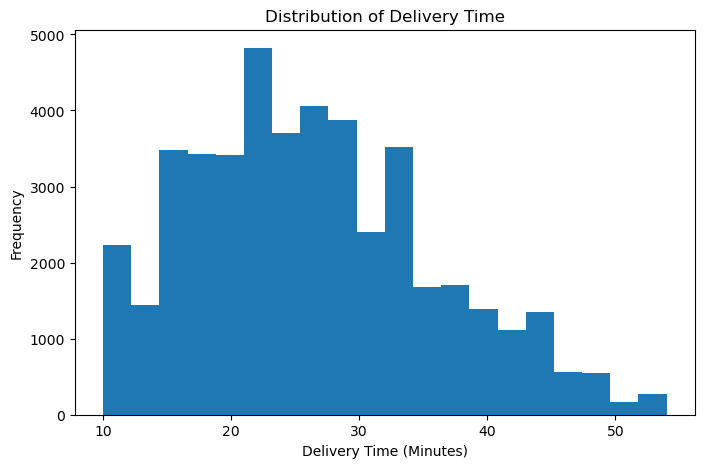

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df['Time_taken(min)'],
    bins=20
)

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Frequency')

plt.show()

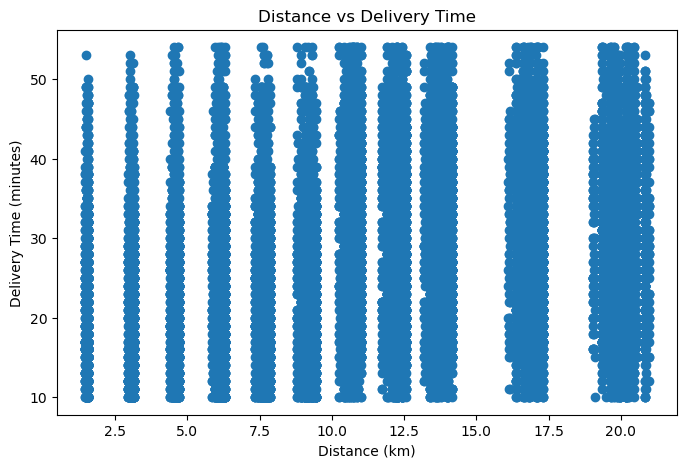

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Distance_km'],
    df['Time_taken(min)']
)

plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (minutes)')
plt.title('Distance vs Delivery Time')

plt.show()

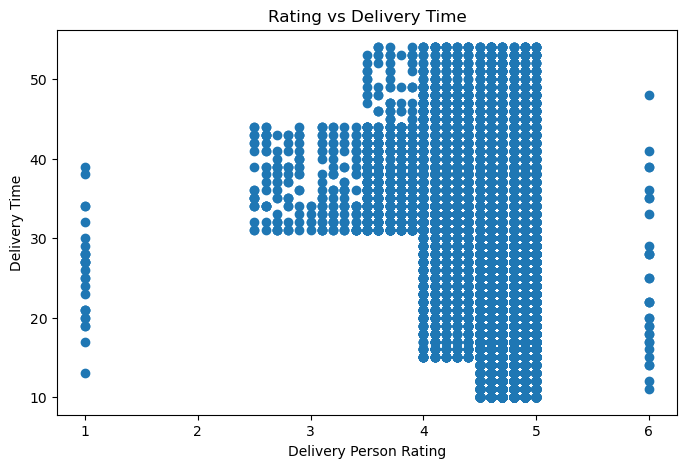

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Delivery_person_Ratings'],
    df['Time_taken(min)']
)

plt.xlabel('Delivery Person Rating')
plt.ylabel('Delivery Time')
plt.title('Rating vs Delivery Time')

plt.show()

In [30]:
vehicle_analysis = df.groupby(
    'Type_of_vehicle'
)['Time_taken(min)'].mean()

print(vehicle_analysis)

Type_of_vehicle
bicycle              26.039216
electric_scooter     24.478400
motorcycle           27.607372
scooter              24.478876
Name: Time_taken(min), dtype: float64


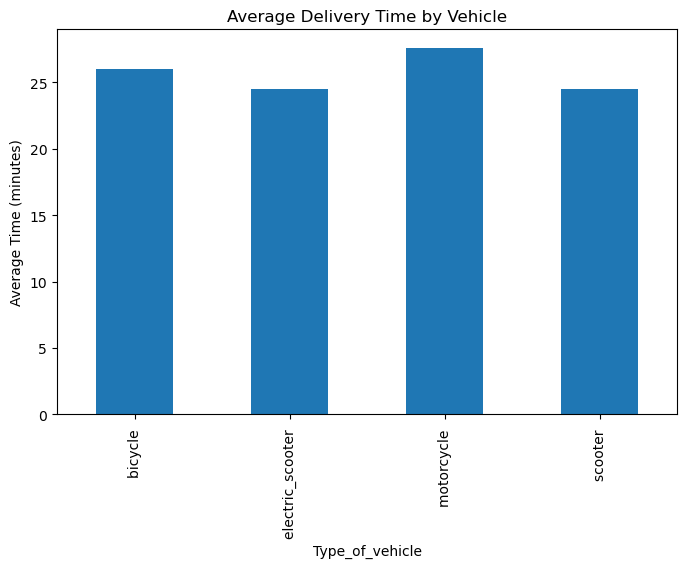

In [31]:
vehicle_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Delivery Time by Vehicle')
plt.ylabel('Average Time (minutes)')

plt.show()

In [32]:
order_analysis = df.groupby(
    'Type_of_order'
)['Time_taken(min)'].mean()

print(order_analysis)

Type_of_order
Buffet     26.292297
Drinks     26.193408
Meal       26.429492
Snack      26.276076
Name: Time_taken(min), dtype: float64


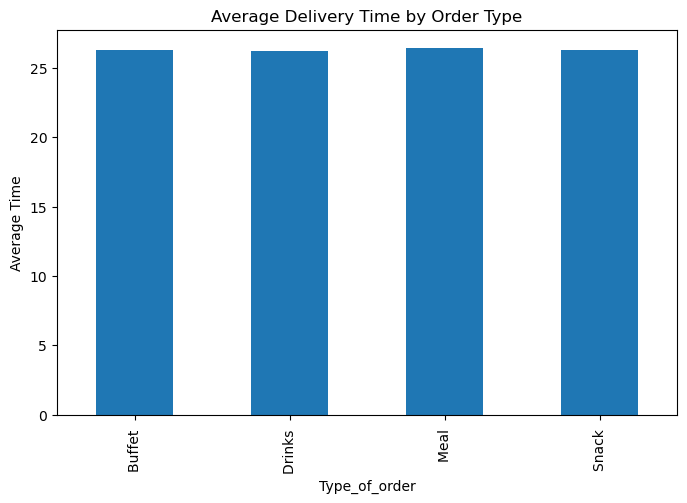

In [33]:
order_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Delivery Time by Order Type')
plt.ylabel('Average Time')

plt.show()

In [34]:
correlation = df[
    [
        'Delivery_person_Age',
        'Delivery_person_Ratings',
        'Distance_km',
        'Time_taken(min)'
    ]
].corr()

print(correlation)

                         Delivery_person_Age  Delivery_person_Ratings  \
Delivery_person_Age                 1.000000                -0.082477   
Delivery_person_Ratings            -0.082477                 1.000000   
Distance_km                        -0.001728                -0.101715   
Time_taken(min)                     0.295763                -0.337176   

                         Distance_km  Time_taken(min)  
Delivery_person_Age        -0.001728         0.295763  
Delivery_person_Ratings    -0.101715        -0.337176  
Distance_km                 1.000000         0.321703  
Time_taken(min)             0.321703         1.000000  


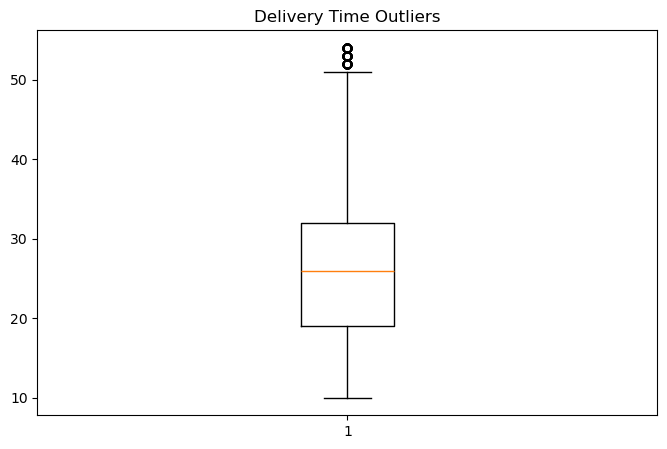

In [36]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df['Time_taken(min)']
)

plt.title('Delivery Time Outliers')

plt.show()

In [37]:
!pip install streamlit

In [38]:
import joblib

joblib.dump(rf_model, 'models/rf_model.pkl')

print("Model saved successfully")

NameError: name 'rf_model' is not defined

In [39]:
# Load cleaned dataset
import pandas as pd

df = pd.read_csv('cleaned_data/food_delivery_cleaned.csv')

df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min),Distance_km,Rider_Experience,Rating_Category,Distance_Category
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24,3.025149,Experienced,High,Short
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33,20.183530,Intermediate,Medium,Long
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26,1.552758,Beginner,Medium,Short
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21,7.790401,Experienced,High,Medium
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30,6.210138,Intermediate,Medium,Medium


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [41]:
X = df[
    [
        'Delivery_person_Age',
        'Delivery_person_Ratings',
        'Distance_km',
        'Type_of_order_encoded',
        'Type_of_vehicle_encoded'
    ]
]

y = df['Time_taken(min)']

KeyError: "['Type_of_order_encoded', 'Type_of_vehicle_encoded'] not in index"

In [42]:
from sklearn.preprocessing import LabelEncoder

# Create encoders
le_order = LabelEncoder()
le_vehicle = LabelEncoder()

# Encode categorical variables
df['Type_of_order_encoded'] = le_order.fit_transform(
    df['Type_of_order']
)

df['Type_of_vehicle_encoded'] = le_vehicle.fit_transform(
    df['Type_of_vehicle']
)

# Verify
df[['Type_of_order',
    'Type_of_order_encoded',
    'Type_of_vehicle',
    'Type_of_vehicle_encoded']].head()

,Type_of_order,Type_of_order_encoded,Type_of_vehicle,Type_of_vehicle_encoded
0,Snack,3,motorcycle,2
1,Snack,3,scooter,3
2,Drinks,1,motorcycle,2
3,Buffet,0,motorcycle,2
4,Snack,3,scooter,3


In [43]:
X = df[
    [
        'Delivery_person_Age',
        'Delivery_person_Ratings',
        'Distance_km',
        'Type_of_order_encoded',
        'Type_of_vehicle_encoded'
    ]
]

y = df['Time_taken(min)']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [46]:
import os
os.makedirs('models', exist_ok=True)

In [47]:
import joblib

joblib.dump(
    rf_model,
    'models/rf_model.pkl'
)

print("Model saved successfully")

Model saved successfully


In [48]:
%%writefile dashboard.py
print("Dashboard file created")

Writing dashboard.py


In [49]:
import os

os.listdir()

['cleaned_data',
 'models',
 'dashboard.py',
 '01_Data_Validation_and_Preprocessing.ipynb',
 '.ipynb_checkpoints',
 'outputs',
 'reports']

In [50]:
%%writefile dashboard.py

import streamlit as st
import pandas as pd
import joblib

# Load trained model
model = joblib.load('models/rf_model.pkl')

# Dashboard title
st.title("🚚 Food Delivery Time Prediction Dashboard")

st.write(
    "Predict food delivery time using delivery partner, distance, and order details."
)

# User inputs
age = st.slider(
    "Delivery Person Age",
    18,
    50,
    30
)

rating = st.slider(
    "Delivery Person Rating",
    1.0,
    5.0,
    4.5
)

distance = st.slider(
    "Distance (km)",
    1.0,
    25.0,
    5.0
)

order = st.selectbox(
    "Type of Order",
    ["Buffet", "Drinks", "Meal", "Snack"]
)

vehicle = st.selectbox(
    "Vehicle Type",
    [
        "bicycle",
        "electric_scooter",
        "motorcycle",
        "scooter"
    ]
)

# Manual encoding
order_map = {
    "Buffet": 0,
    "Drinks": 1,
    "Meal": 2,
    "Snack": 3
}

vehicle_map = {
    "bicycle": 0,
    "electric_scooter": 1,
    "motorcycle": 2,
    "scooter": 3
}

# Create input dataframe
input_data = pd.DataFrame({
    "Delivery_person_Age": [age],
    "Delivery_person_Ratings": [rating],
    "Distance_km": [distance],
    "Type_of_order_encoded": [order_map[order]],
    "Type_of_vehicle_encoded": [vehicle_map[vehicle]]
})

# Prediction button
if st.button("Predict Delivery Time"):
    
    prediction = model.predict(input_data)

    st.success(
        f"Estimated Delivery Time: {prediction[0]:.2f} minutes"
    )

Overwriting dashboard.py


In [51]:
import os
os.listdir()

['cleaned_data',
 'models',
 'dashboard.py',
 '01_Data_Validation_and_Preprocessing.ipynb',
 '.ipynb_checkpoints',
 'outputs',
 'reports']

In [52]:
!pip install streamlit

In [53]:
import os

print(os.getcwd())
print(os.listdir())

/Users/tridhajain/Desktop/Food_Delivery_Optimization/notebooks
['cleaned_data', 'models', 'dashboard.py', '01_Data_Validation_and_Preprocessing.ipynb', '.ipynb_checkpoints', 'outputs', 'reports']


In [55]:
# Import libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import joblib

# Select features
X = df[
    [
        'Delivery_person_Age',
        'Delivery_person_Ratings',
        'Distance_km',
        'Type_of_order_encoded',
        'Type_of_vehicle_encoded'
    ]
]

# Target variable
y = df['Time_taken(min)']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Save model
joblib.dump(rf_model, 'models/rf_model.pkl')

print("Model saved successfully")

Model saved successfully
